<h1><b>Configuración y librerías

In [12]:
# Librerías
import torch
import numpy as np
import random
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.functional as TF

from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet18
from copy import deepcopy
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             f1_score, recall_score, precision_score)
from torchvision.models import efficientnet_b0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [13]:
# Rutas
DATOS_DIR = Path("../preprocesamiento/output/center_3/preprocesamiento_train")
TEST_DIR = Path("../preprocesamiento/output/center_3/preprocesamiento_test")

# Uso GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# HIPERPARÁMETROS
BATCH_SIZE = 16      # imágenes por batch
EPOCHS     = 30      # número de épocas
LR         = 0.0004    # learning rate
VAL_SPLIT  = 0.2     # 20% para validación

Dispositivo: cuda


In [14]:
# Semilla para reproducibilidad
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)          # ← cubre todas las GPUs, no solo 1
    torch.backends.cudnn.deterministic = True  # ← operaciones CUDA deterministas
    torch.backends.cudnn.benchmark = False     # ← desactiva autotuner no determinista

set_seed(SEED)

<h1><b>Dataset

In [15]:
class StrokeDataset(Dataset):

    def __init__(self, archivos, augment=False):
        self.archivos = archivos
        self.augment  = augment

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        if self.augment:
            if random.random() > 0.5:
                imagen = TF.hflip(imagen)
            if random.random() > 0.5:
                imagen = TF.vflip(imagen)
            if random.random() > 0.5:
                angle  = random.uniform(-15, 15)
                imagen = TF.rotate(imagen, angle)

        nombre = ruta.stem
        label  = 1 if "STROKE" in nombre else 0
        return imagen, torch.tensor(label, dtype=torch.float32)


# Verificación
todos_los_archivos = sorted(DATOS_DIR.glob("*.npy"))

print(f"Total archivos : {len(todos_los_archivos)}")

strokes   = sum(1 for f in todos_los_archivos if "STROKE"  in f.stem)
controles = sum(1 for f in todos_los_archivos if "CONTROL" in f.stem)
print(f"STROKE         : {strokes}")
print(f"CONTROL        : {controles}")

dataset_prueba = StrokeDataset(todos_los_archivos)
imagen, label  = dataset_prueba[0]
print(f"\nEjemplo cargado:")
print(f"  Shape  : {imagen.shape}")
print(f"  Label  : {label.item()} ({'STROKE' if label.item()==1 else 'CONTROL'})")

Total archivos : 679
STROKE         : 427
CONTROL        : 252

Ejemplo cargado:
  Shape  : torch.Size([2, 112, 112])
  Label  : 0.0 (CONTROL)


<h1><b>Split y DataLoader

In [16]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    
g = torch.Generator()
g.manual_seed(SEED)

In [17]:
total    = len(todos_los_archivos)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size

archivos_train, archivos_val = random_split(
    todos_los_archivos,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Convertir a lista para pasarlos al Dataset
archivos_train = [todos_los_archivos[i] for i in archivos_train.indices]
archivos_val   = [todos_los_archivos[i] for i in archivos_val.indices]

# Dataset
dataset_train = StrokeDataset(archivos_train, augment=True)
dataset_val   = StrokeDataset(archivos_val,   augment=False)
# DataLoader
loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    worker_init_fn=seed_worker,   # cada worker arranca con seed fija
    generator=g                   # controla el shuffle
)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False)

# Verificación
print(f"Train : {len(dataset_train)} muestras | {len(loader_train)} batches")
print(f"Val   : {len(dataset_val)}  muestras | {len(loader_val)} batches")

imagenes, labels = next(iter(loader_train))
print(f"\nBatch de prueba:")
print(f"  Imágenes : {imagenes.shape}")
print(f"  Labels   : {labels.shape} | {labels}")

Train : 544 muestras | 34 batches
Val   : 135  muestras | 9 batches

Batch de prueba:
  Imágenes : torch.Size([16, 2, 112, 112])
  Labels   : torch.Size([16]) | tensor([1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0.])


<h1> <b> Modelo de entrenamiento

In [69]:
# Qué canales importan más
class ChannelAttention(nn.Module):
    def __init__(self, canales, reduccion=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(canales, canales // reduccion),
            nn.ReLU(),
            nn.Linear(canales // reduccion, canales)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.mlp(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x

# Qué zonas de la imagen importan más
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_ = x.max(dim=1, keepdim=True).values
        mapa = torch.cat([avg, max_], dim=1)
        return self.sigmoid(self.conv(mapa)) * x


class CBAM(nn.Module):
    def __init__(self, canales):
        super().__init__()
        self.channel = ChannelAttention(canales)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

In [91]:
# Arquitectura ResNet-18 con CBAM
class ResNet18CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet-18 base
        base = resnet18(weights=None)

        # Primera capa: 3 canales a 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Guardamos las capas de ResNet
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        # CBAM después de cada capa residual
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

        # Clasificador final: 1 neurona para STROKE/CONTROL
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))

        x = self.cbam1(self.layer1(x))
        x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x))
        x = self.cbam4(self.layer4(x))

        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x

In [92]:
set_seed(SEED)
modelo = ResNet18CBAM().to(DEVICE)

# Pasar un batch de prueba
with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())

print(f"Entrada : {imagenes.shape}")
print(f"Salida  : {salida.shape}")
print(f"Parámetros totales: {total_params:,}")

Entrada : torch.Size([16, 2, 112, 112])
Salida  : torch.Size([16, 1])
Parámetros totales: 11,218,825


<h1><b> Entrenamiento

In [93]:
# Focal Loss para center_3
# Para center_3 — confundido en ambas clases
# gamma controla cuánto se enfoca en ejemplos difíciles
# gamma=2 es el estándar de la literatura
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        loss  = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

In [94]:
criterio  = FocalLoss(gamma=2.0)            # Loss para clasificación binaria
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Early stopping
PACIENCIA        = 7      # épocas sin mejora antes de parar
mejor_val_loss   = float("inf")
epocas_sin_mejora = 0
mejor_modelo     = None

# Ruta donde guardar el mejor modelo
MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "resnet18_cbam_mejor.pth"

# Loop de entrenamiento
historial = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    # TRAIN
    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()

        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    # VALIDACIÓN
    modelo.eval()
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)

            salida  = modelo(imagenes)
            loss    = criterio(salida, labels)

            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    # METRICAS
    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)

    scheduler.step()

    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    # GUARDAR MEJOR MODELO
    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")

    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    # EARLY STOPPING
    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

Época 01/30 | Train loss: 0.1478 acc: 0.6875 | Val loss: 0.1129 acc: 0.7630 | 1.8s
  ✔ Mejor modelo guardado (val_loss: 0.1129)
Época 02/30 | Train loss: 0.1056 acc: 0.8254 | Val loss: 0.1201 acc: 0.7630 | 1.7s
  Sin mejora 1/7
Época 03/30 | Train loss: 0.0734 acc: 0.8860 | Val loss: 0.1084 acc: 0.7704 | 1.7s
  ✔ Mejor modelo guardado (val_loss: 0.1084)
Época 04/30 | Train loss: 0.0358 acc: 0.9651 | Val loss: 0.5753 acc: 0.6593 | 1.7s
  Sin mejora 1/7
Época 05/30 | Train loss: 0.0438 acc: 0.9210 | Val loss: 0.0990 acc: 0.8370 | 1.7s
  ✔ Mejor modelo guardado (val_loss: 0.0990)
Época 06/30 | Train loss: 0.0394 acc: 0.9559 | Val loss: 0.1222 acc: 0.8444 | 1.7s
  Sin mejora 1/7
Época 07/30 | Train loss: 0.0292 acc: 0.9688 | Val loss: 0.1066 acc: 0.8741 | 1.7s
  Sin mejora 2/7
Época 08/30 | Train loss: 0.0131 acc: 0.9835 | Val loss: 0.1179 acc: 0.8593 | 1.7s
  Sin mejora 3/7
Época 09/30 | Train loss: 0.0167 acc: 0.9835 | Val loss: 0.2211 acc: 0.7630 | 1.7s
  Sin mejora 4/7
Época 10/30 | Tr

<h1> <b> Evaluación

In [95]:
archivos_test = sorted(TEST_DIR.glob("*.npy"))

print(f"Total test : {len(archivos_test)}")
print(f"STROKE     : {sum(1 for f in archivos_test if 'STROKE'  in f.stem)}")
print(f"CONTROL    : {sum(1 for f in archivos_test if 'CONTROL' in f.stem)}")

# Dataset y loader
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

# Cargar el mejor modelo
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)

print("RESULTADOS — VALIDACIÓN")

print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

Total test : 171
STROKE     : 107
CONTROL    : 64
RESULTADOS — VALIDACIÓN
  AUC-ROC       : 0.5524
  Accuracy      : 0.5380
  F1-Score      : 0.5949
  Sensibilidad  : 0.5421  (detecta STROKE)
  Especificidad : 0.5312  (detecta CONTROL)
  Precisión     : 0.6591


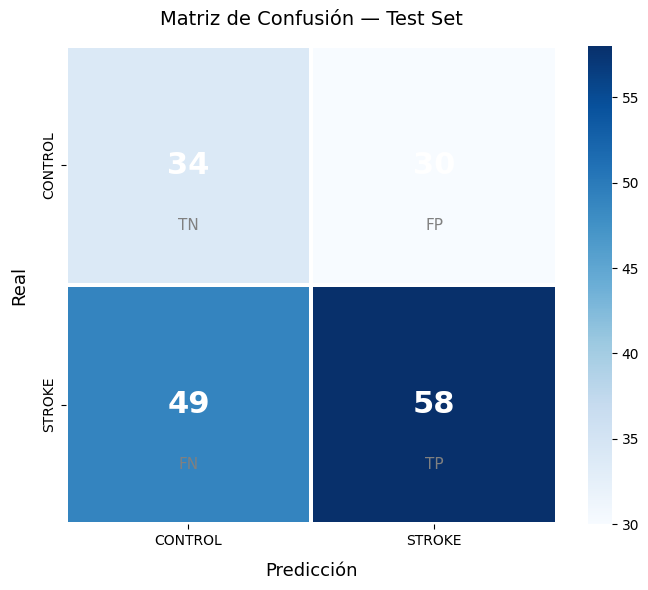

In [96]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h1><b> Entrenamiento sin CBAM

In [97]:
class ResNet18Base(nn.Module):
    def __init__(self):
        super().__init__()

        base = resnet18(weights=None)

        # Modificamos la primera capa: 3 canales - 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x


# Verificación
set_seed(SEED)
modelo_base = ResNet18Base().to(DEVICE)

with torch.no_grad():
    salida = modelo_base(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo_base.parameters())
print(f"Entrada    : {imagenes.shape}")
print(f"Salida     : {salida.shape}")
print(f"Parámetros : {total_params:,}")

Entrada    : torch.Size([11, 2, 112, 112])
Salida     : torch.Size([11, 1])
Parámetros : 11,173,889


In [98]:
set_seed(SEED)
# Recrear el generator para que el shuffle empiece igual
g = torch.Generator()
g.manual_seed(SEED)
loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g
)

In [99]:
# ENTRENAMIENTO — ResNet18 SIN CBAM
criterio  = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(modelo_base.parameters(), lr=LR)  # ← modelo_base
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_loss    = float("inf")
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_PATH_BASE = MODELO_DIR / "resnet18_base_mejor.pth"  # nombre distinto

historial_base = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    modelo_base.train()  # ← modelo_base
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo_base(imagenes)  # ← modelo_base
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    modelo_base.eval()  # ← modelo_base
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo_base(imagenes)  # modelo_base
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial_base["train_loss"].append(train_loss)
    historial_base["val_loss"].append(val_loss)
    historial_base["train_acc"].append(train_acc)
    historial_base["val_acc"].append(val_acc)

    scheduler.step()
    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo_base.state_dict())
        torch.save(mejor_modelo, MODELO_PATH_BASE)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH_BASE}")

Época 01/30 | Train loss: 0.1597 acc: 0.7059 | Val loss: 0.5969 acc: 0.6519 | 1.5s
  ✔ Mejor modelo guardado (val_loss: 0.5969)
Época 02/30 | Train loss: 0.0882 acc: 0.8658 | Val loss: 0.1271 acc: 0.8148 | 1.6s
  ✔ Mejor modelo guardado (val_loss: 0.1271)
Época 03/30 | Train loss: 0.0451 acc: 0.9246 | Val loss: 0.1913 acc: 0.7630 | 1.5s
  Sin mejora 1/7
Época 04/30 | Train loss: 0.0386 acc: 0.9357 | Val loss: 0.9410 acc: 0.6519 | 1.5s
  Sin mejora 2/7
Época 05/30 | Train loss: 0.0419 acc: 0.9375 | Val loss: 0.1367 acc: 0.7630 | 1.5s
  Sin mejora 3/7
Época 06/30 | Train loss: 0.0145 acc: 0.9835 | Val loss: 0.1589 acc: 0.8222 | 1.5s
  Sin mejora 4/7
Época 07/30 | Train loss: 0.0297 acc: 0.9522 | Val loss: 0.0794 acc: 0.8519 | 1.5s
  ✔ Mejor modelo guardado (val_loss: 0.0794)
Época 08/30 | Train loss: 0.0243 acc: 0.9669 | Val loss: 0.1495 acc: 0.8148 | 1.5s
  Sin mejora 1/7
Época 09/30 | Train loss: 0.0061 acc: 0.9890 | Val loss: 0.1477 acc: 0.8222 | 1.5s
  Sin mejora 2/7
Época 10/30 | Tr

In [100]:
# Cargar el mejor modelo base
modelo_base.load_state_dict(torch.load(MODELO_PATH_BASE, map_location=DEVICE))  # ← base
modelo_base.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo_base(imagenes)  # ← base
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)


print(" RESULTADOS — TEST SET (Sin CBAM)")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")


 RESULTADOS — TEST SET (Sin CBAM)
  AUC-ROC       : 0.7445
  Accuracy      : 0.5848
  F1-Score      : 0.5359
  Sensibilidad  : 0.3832  (detecta STROKE)
  Especificidad : 0.9219  (detecta CONTROL)
  Precisión     : 0.8913


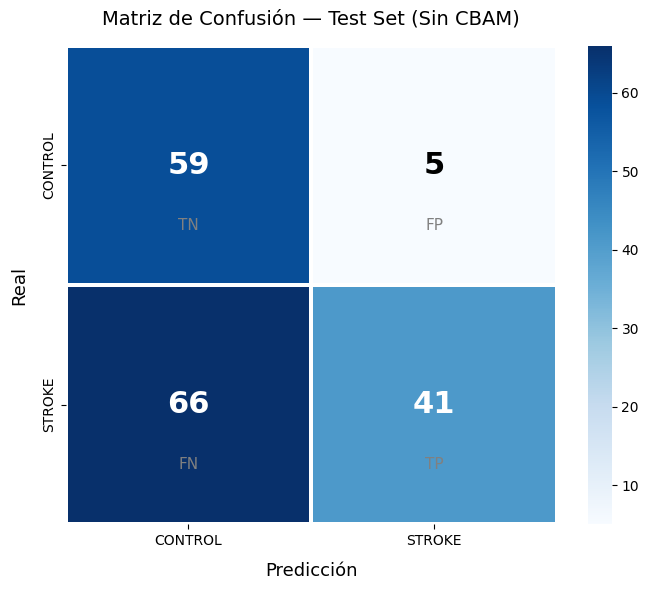

In [101]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set (Sin CBAM)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# **Efficent-B0**

In [18]:
class EfficientNetB0(nn.Module):
    def __init__(self):
        super().__init__()

        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Adaptar primera capa de 3 a 2 canales
        old_weight = base.features[0][0].weight.data
        new_weight = old_weight[:, :2, :, :].clone() * (3 / 2)

        new_conv = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1, bias=False)
        new_conv.weight = nn.Parameter(new_weight)
        base.features[0][0] = new_conv

        self.features  = base.features
        self.avgpool   = nn.AdaptiveAvgPool2d(1)
        self.fc        = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x).flatten(1)
        x = self.fc(x)
        return x

modelo = EfficientNetB0().to(DEVICE)

with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())
print(f"Entrada      : {imagenes.shape}")
print(f"Salida       : {salida.shape}")
print(f"Parámetros   : {total_params:,}")

Entrada      : torch.Size([16, 2, 112, 112])
Salida       : torch.Size([16, 1])
Parámetros   : 4,008,541


In [93]:
# Desbalance corregido
n_control  = sum(1 for f in archivos_train if "CONTROL" in f.stem)
n_stroke   = sum(1 for f in archivos_train if "STROKE"  in f.stem)
pos_weight = torch.tensor([n_stroke / n_control], dtype=torch.float32).to(DEVICE)
print(f"CONTROL: {n_control} | STROKE: {n_stroke} | pos_weight: {pos_weight.item():.3f}")

criterio  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_auc     = 0.0
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "efficientnet_mejor_center_3.pth"

historial = {"train_loss": [], "val_loss": [],
             "train_acc":  [], "val_acc":  [], "val_auc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    # ── Val ────────────────────────────────────────────────────────────────
    modelo.eval()
    val_loss, val_correctos = 0.0, 0
    all_probs, all_labels   = [], []

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo(imagenes)
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            probs         = torch.sigmoid(salida)
            preds         = (probs >= 0.5).float()
            val_correctos += (preds == labels).sum().item()
            all_probs.extend(probs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)
    val_auc     = roc_auc_score(all_labels, all_probs)
    scheduler.step()
    tiempo      = time.time() - inicio

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)
    historial["val_auc"].append(val_auc)

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} auc: {val_auc:.4f} | "
          f"{tiempo:.1f}s")

    if val_auc > mejor_val_auc:
        mejor_val_auc     = val_auc
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_auc: {mejor_val_auc:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_auc: {mejor_val_auc:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

CONTROL: 204 | STROKE: 340 | pos_weight: 1.667
Época 01/30 | Train loss: 0.7027 acc: 0.6985 | Val loss: 0.6728 acc: 0.6963 auc: 0.7792 | 2.5s
  ✔ Mejor modelo guardado (val_auc: 0.7792)
Época 02/30 | Train loss: 0.5177 acc: 0.7886 | Val loss: 0.6918 acc: 0.7926 auc: 0.8702 | 2.3s
  ✔ Mejor modelo guardado (val_auc: 0.8702)
Época 03/30 | Train loss: 0.3821 acc: 0.8750 | Val loss: 0.4147 acc: 0.8444 auc: 0.9392 | 2.3s
  ✔ Mejor modelo guardado (val_auc: 0.9392)
Época 04/30 | Train loss: 0.2614 acc: 0.9118 | Val loss: 0.5349 acc: 0.9037 auc: 0.9516 | 2.3s
  ✔ Mejor modelo guardado (val_auc: 0.9516)
Época 05/30 | Train loss: 0.3511 acc: 0.9081 | Val loss: 0.3369 acc: 0.8815 auc: 0.9624 | 2.2s
  ✔ Mejor modelo guardado (val_auc: 0.9624)
Época 06/30 | Train loss: 0.2766 acc: 0.9210 | Val loss: 0.3008 acc: 0.9259 auc: 0.9696 | 2.2s
  ✔ Mejor modelo guardado (val_auc: 0.9696)
Época 07/30 | Train loss: 0.2089 acc: 0.9412 | Val loss: 0.6735 acc: 0.8889 auc: 0.9598 | 2.2s
  Sin mejora 1/7
Época 0

In [5]:
MODELO_DIR  = Path("modelos")
MODELO_PATH = MODELO_DIR / "efficientnet_mejor_center_3.pth"
print(MODELO_PATH)
print(MODELO_PATH.exists())

modelos\efficientnet_mejor_center_3.pth
True


In [19]:
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Dataset y loader
archivos_test = sorted(TEST_DIR.glob("*.npy"))
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.03).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)


print("   RESULTADOS — TEST (EfficientNet-B0)")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

   RESULTADOS — TEST (EfficientNet-B0)
  AUC-ROC       : 0.8216
  Accuracy      : 0.7193
  F1-Score      : 0.7624
  Sensibilidad  : 0.7196  (detecta STROKE)
  Especificidad : 0.7188  (detecta CONTROL)
  Precisión     : 0.8105


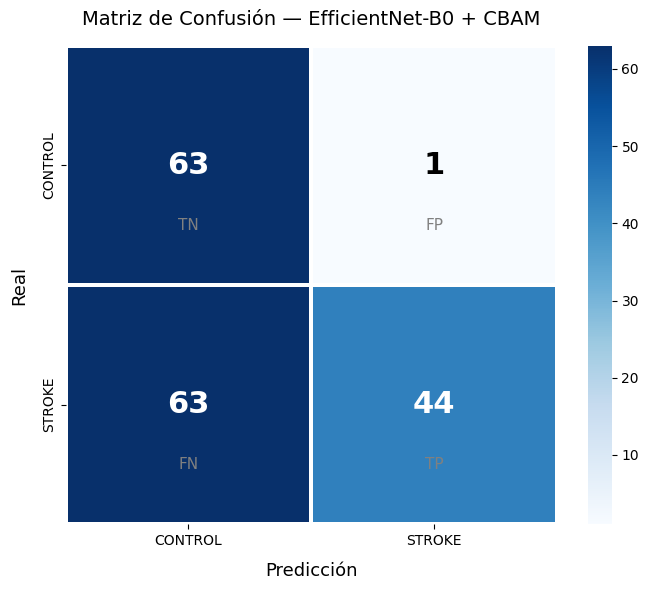

In [106]:
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — EfficientNet-B0 + CBAM", fontsize=14, pad=15)
plt.tight_layout()
plt.show()